In [7]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
%pip install plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import seaborn as sns
import plotly.express as px

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df = pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [10]:
df.shape

(2938, 22)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [12]:
df.size

64636

In [13]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [14]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [15]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [16]:
# check % of null value to drop that column, sum?
df.isnull().sum()/df.shape[0]*100

Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
 BMI                                1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
 HIV/AIDS                           0.000000
GDP                                15.248468
Population                         22.191967
 thinness  1-19 years               1.157250
 thinness 5-9 years                 1.157250
Income composition of resources     5.684139
Schooling                           5.547992
dtype: flo

In [17]:
# mean on simple data
for i in['Alcohol',' BMI ','Income composition of resources']:
    df[i].fillna(df[i].mean(),inplace=True)

C:\Users\pds\AppData\Local\Temp\ipykernel_13892\3021301592.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)


In [18]:
# median on simple data
for i in['Life expectancy ','Adult Mortality','Hepatitis B','Polio','Total expenditure','Diphtheria ','GDP','Population',' thinness  1-19 years',' thinness 5-9 years','Schooling']:
    df[i].fillna(df[i].median(),inplace=True)

C:\Users\pds\AppData\Local\Temp\ipykernel_13892\3673675122.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)
C:\Users\pds\AppData\Local\Temp\ipykernel_13892\3673675122.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [19]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

# Handling Outliears

In [20]:
def whisker(col):
    Q1=col.quantile(0.25)
    Q3=col.quantile(0.75)
    IQR=Q3-Q1
    lb=Q1-1.5*IQR
    ub=Q3+1.5*IQR
    return lb, ub

In [21]:
whisker(df['Population'])

(np.float64(-5829263.75), np.float64(10832552.25))

In [22]:
whisker(df['GDP'])

(np.float64(-5717.890296249999), np.float64(11077.782481749999))

In [23]:
for i in ['percentage expenditure','Total expenditure',' HIV/AIDS','GDP',' thinness  1-19 years',' thinness 5-9 years','Schooling']:
    lb,ub = whisker(df[i])
    df[i] = np.where(df[i]<lb, lb, df[i])
    df[i] = np.where(df[i]>ub, ub, df[i])


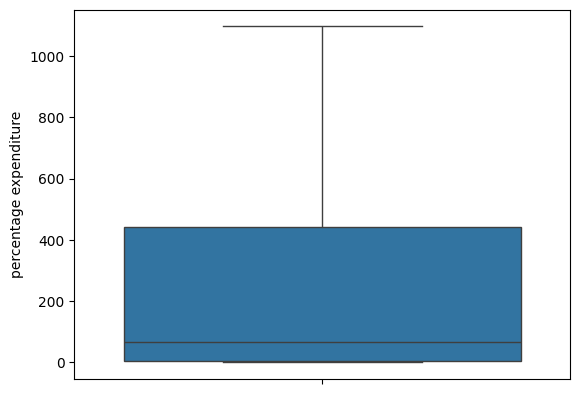

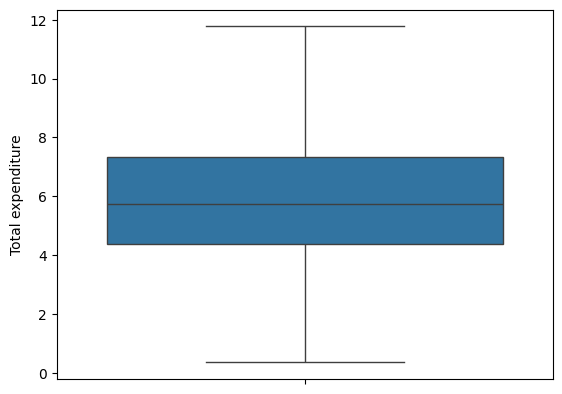

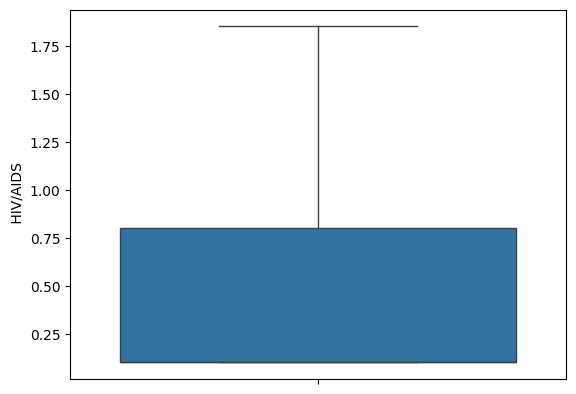

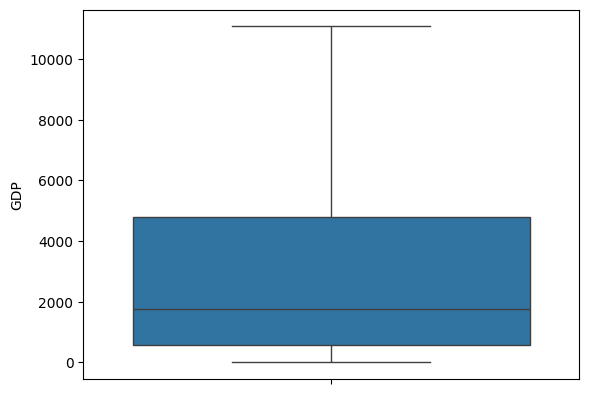

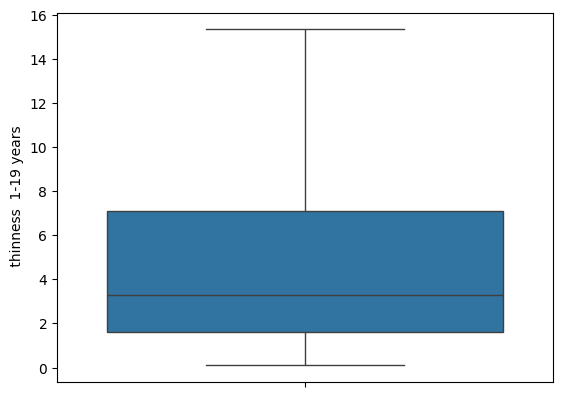

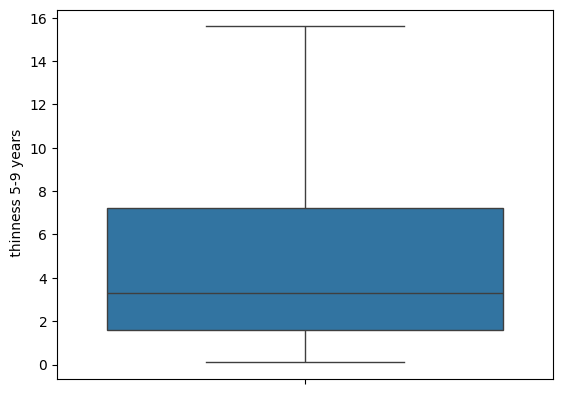

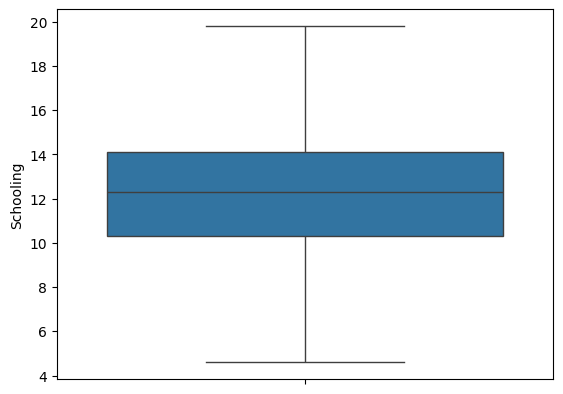

In [24]:
for i in ['percentage expenditure','Total expenditure',' HIV/AIDS','GDP',' thinness  1-19 years',' thinness 5-9 years','Schooling']:
    sns.boxplot(df[i])
    plt.show()

In [25]:
df.select_dtypes(include='object').columns

Index(['Country', 'Status'], dtype='object')

In [26]:
df.Country.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', "Côte d'Ivoire", 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia',
       'Georgia', 'Germany'

# encoding

In [27]:
df.Status.unique()

array(['Developing', 'Developed'], dtype=object)

In [28]:
df.select_dtypes(include='object').columns

Index(['Country', 'Status'], dtype='object')

In [29]:
a = df.Country.unique()
len(a)

193

In [30]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Status']= label_encoder.fit_transform(df['Status'])

In [31]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.10,584.259210,33736494.0,15.35,15.6,0.479,10.1
1,Afghanistan,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.10,612.696514,327582.0,15.35,15.6,0.476,10.0
2,Afghanistan,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.10,631.744976,31731688.0,15.35,15.6,0.470,9.9
3,Afghanistan,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.10,669.959000,3696958.0,15.35,15.6,0.463,9.8
4,Afghanistan,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.10,63.537231,2978599.0,15.35,15.6,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,1.85,454.366654,12777511.0,9.40,9.4,0.407,9.2
2934,Zimbabwe,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,1.85,453.351155,12633897.0,9.80,9.9,0.418,9.5
2935,Zimbabwe,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,1.85,57.348340,125525.0,1.20,1.3,0.427,10.0
2936,Zimbabwe,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,1.85,548.587312,12366165.0,1.60,1.7,0.427,9.8


In [32]:
# complete row 115
df.iloc[115]

Country                               Australia
Year                                       2012
Status                                        0
Life expectancy                            82.3
Adult Mortality                            61.0
infant deaths                                 1
Alcohol                                   10.03
percentage expenditure              1096.807347
Hepatitis B                                91.0
Measles                                     199
 BMI                                       65.0
under-five deaths                             1
Polio                                      92.0
Total expenditure                          9.36
Diphtheria                                 92.0
 HIV/AIDS                                   0.1
GDP                                11077.782482
Population                           22728254.0
 thinness  1-19 years                       0.6
 thinness 5-9 years                         0.6
Income composition of resources         

# Frequency Encoding

In [33]:
# frequency encoding, map use for replace
# means it replace each value with how often it appears
# first map frequwncy then replace in dataset
freq_map = df['Country'].value_counts()
freq_map

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Monaco                    1
Marshall Islands          1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

In [34]:
# normalize=True use for value count in percentage
freq_map = df['Country'].value_counts(normalize=True)
freq_map

Country
Afghanistan              0.005446
Albania                  0.005446
Algeria                  0.005446
Angola                   0.005446
Antigua and Barbuda      0.005446
                           ...   
Monaco                   0.000340
Marshall Islands         0.000340
Saint Kitts and Nevis    0.000340
San Marino               0.000340
Tuvalu                   0.000340
Name: proportion, Length: 193, dtype: float64

In [35]:
df['Country']=df['Country'].map(freq_map)

In [36]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.005446,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.10,584.259210,33736494.0,15.35,15.6,0.479,10.1
1,0.005446,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.10,612.696514,327582.0,15.35,15.6,0.476,10.0
2,0.005446,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.10,631.744976,31731688.0,15.35,15.6,0.470,9.9
3,0.005446,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.10,669.959000,3696958.0,15.35,15.6,0.463,9.8
4,0.005446,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.10,63.537231,2978599.0,15.35,15.6,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0.005446,2004,1,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,1.85,454.366654,12777511.0,9.40,9.4,0.407,9.2
2934,0.005446,2003,1,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,1.85,453.351155,12633897.0,9.80,9.9,0.418,9.5
2935,0.005446,2002,1,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,1.85,57.348340,125525.0,1.20,1.3,0.427,10.0
2936,0.005446,2001,1,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,1.85,548.587312,12366165.0,1.60,1.7,0.427,9.8


In [37]:
df['Country']

0       0.005446
1       0.005446
2       0.005446
3       0.005446
4       0.005446
          ...   
2933    0.005446
2934    0.005446
2935    0.005446
2936    0.005446
2937    0.005446
Name: Country, Length: 2938, dtype: float64

# feature scaling

In [38]:
# can't apply or need on encoded
# feature scaling uses on continuous numerical
# first identify, then find ranges by stracting max, min
# targated or encoded columns k ilawa feature scaling apply, id, years
numerical_feature = df.select_dtypes(include=['int64','float64']).columns
numerical_feature

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [39]:
for i in numerical_feature:
    column_range = df[i].max() - df[i].min()
    print(f'range of {i}: {column_range}')

range of Country: 0.005105513955071477
range of Year: 15
range of Status: 1
range of Life expectancy : 52.7
range of Adult Mortality: 722.0
range of infant deaths: 1800
range of Alcohol: 17.86
range of percentage expenditure: 1096.807346997125
range of Hepatitis B: 98.0
range of Measles : 212183
range of  BMI : 86.3
range of under-five deaths : 2500
range of Polio: 96.0
range of Total expenditure: 11.4
range of Diphtheria : 97.0
range of  HIV/AIDS: 1.75
range of GDP: 11076.101131749998
range of Population: 1293859260.0
range of  thinness  1-19 years: 15.25
range of  thinness 5-9 years: 15.499999999999998
range of Income composition of resources: 0.948
range of Schooling: 15.199999999999996


# StandardScaler

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
df[[ 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']]=scaler.fit_transform(df[[ 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']])

In [42]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [43]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.005446,2015,1,65.0,0.792119,0.268824,-1.172958,-0.546410,-0.783807,-0.110384,...,-3.279423,0.991344,-0.735391,-0.629209,-0.756835,0.435183,2.711459,2.740246,-0.725401,-0.632374
1,0.005446,2014,1,59.9,0.856601,0.285786,-1.172958,-0.540647,-0.914281,-0.168124,...,-1.053699,1.000080,-0.862233,-0.629209,-0.749306,-0.183349,2.711459,2.740246,-0.740050,-0.664624
2,0.005446,2013,1,59.9,0.832421,0.302749,-1.172958,-0.541429,-0.827298,-0.173531,...,-0.882489,0.978240,-0.777671,-0.629209,-0.744263,0.398066,2.711459,2.740246,-0.769349,-0.696875
3,0.005446,2012,1,59.5,0.864662,0.328193,-1.172958,-0.528678,-0.696824,0.032045,...,-0.668478,1.148594,-0.650830,-0.629209,-0.734146,-0.120968,2.711459,2.740246,-0.803531,-0.729125
4,0.005446,2011,1,59.2,0.888843,0.345155,-1.172958,-0.711239,-0.653333,0.051757,...,-0.625675,0.864671,-0.608549,-0.629209,-0.894692,-0.134268,2.711459,2.740246,-0.847480,-0.825876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0.005446,2004,1,44.3,4.499850,-0.028022,-0.062024,-0.729465,-0.653333,-0.208332,...,-0.668478,0.541437,-0.735391,1.895041,-0.791223,0.047149,1.198386,1.180722,-1.076989,-0.922627
2934,0.005446,2003,1,44.5,4.435368,-0.036503,-0.138640,-0.729465,-3.306306,-0.123991,...,-3.236620,0.274987,-0.608549,1.895041,-0.791492,0.044490,1.300105,1.306490,-1.023274,-0.825876
2935,0.005446,2002,1,44.8,-0.739335,-0.044984,-0.044146,-0.729465,-0.435876,-0.184521,...,-0.411663,0.279355,-0.481708,1.895041,-0.896330,-0.187090,-0.886858,-0.856721,-0.979326,-0.664624
2936,0.005446,2001,1,45.3,4.201620,-0.044984,-0.736246,-0.729465,-0.305402,-0.164897,...,-0.283256,0.117738,-0.312585,1.895041,-0.766279,0.039533,-0.785139,-0.756107,-0.979326,-0.729125


In [44]:
s = df.select_dtypes(include='number').corr()
s

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Country,1.000000,-0.069440,-0.026848,-0.017612,0.009763,0.015020,0.048963,0.022791,0.017594,0.012333,...,-0.001206,-0.030263,-0.001747,0.036771,0.024205,0.009869,0.049302,0.049479,-0.010455,0.017920
Year,-0.069440,1.000000,0.001864,0.170819,-0.079535,-0.037415,-0.048168,0.032619,0.021302,-0.082493,...,0.091388,0.073218,0.131373,-0.089499,0.132267,0.014027,-0.049312,-0.049736,0.236333,0.199218
Status,-0.026848,0.001864,1.000000,-0.481415,0.314894,0.112252,-0.579371,-0.421979,-0.127008,0.076955,...,-0.218628,-0.287034,-0.215281,0.289058,-0.432258,0.037606,0.393320,0.393960,-0.457302,-0.509512
Life expectancy,-0.017612,0.170819,-0.481415,1.000000,-0.696390,-0.196769,0.390675,0.487023,0.170219,-0.157767,...,0.458399,0.212162,0.472211,-0.796123,0.525770,-0.029014,-0.507258,-0.504529,0.692560,0.736385
Adult Mortality,0.009763,-0.079535,0.314894,-0.696390,1.000000,0.078890,-0.189921,-0.310339,-0.123287,0.031293,...,-0.270002,-0.109905,-0.270301,0.602622,-0.332709,-0.005292,0.331235,0.338506,-0.440143,-0.443935
infant deaths,0.015020,-0.037415,0.112252,-0.196769,0.078890,1.000000,-0.113812,-0.143889,-0.167421,0.501128,...,-0.170896,-0.130846,-0.175376,0.098659,-0.151151,0.551667,0.315402,0.317090,-0.143663,-0.202738
Alcohol,0.048963,-0.048168,-0.579371,0.390675,-0.189921,-0.113812,1.000000,0.386472,0.091298,-0.051055,...,0.212395,0.304278,0.213878,-0.190389,0.401976,-0.027341,-0.433802,-0.424124,0.416099,0.519665
percentage expenditure,0.022791,0.032619,-0.421979,0.487023,-0.310339,-0.143889,0.386472,1.000000,0.075726,-0.103376,...,0.213900,0.187387,0.208413,-0.294376,0.852545,-0.027291,-0.328551,-0.330494,0.489833,0.525224
Hepatitis B,0.017594,0.021302,-0.127008,0.170219,-0.123287,-0.167421,0.091298,0.075726,1.000000,-0.073021,...,0.364890,0.063706,0.449151,-0.143249,0.109610,-0.125006,-0.079854,-0.084438,0.117516,0.152076
Measles,0.012333,-0.082493,0.076955,-0.157767,0.031293,0.501128,-0.051055,-0.103376,-0.073021,1.000000,...,-0.136669,-0.106298,-0.142385,0.106212,-0.103267,0.237188,0.187274,0.184070,-0.115764,-0.126793


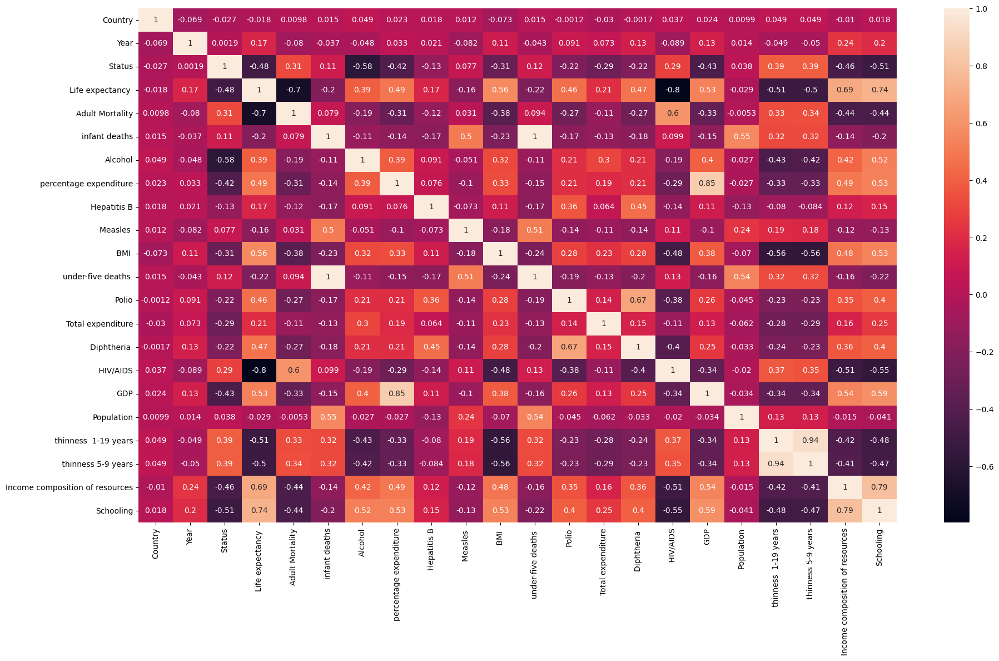

In [45]:
plt.figure(figsize=(22,12))
sns.heatmap(s,annot=True)
plt.show()

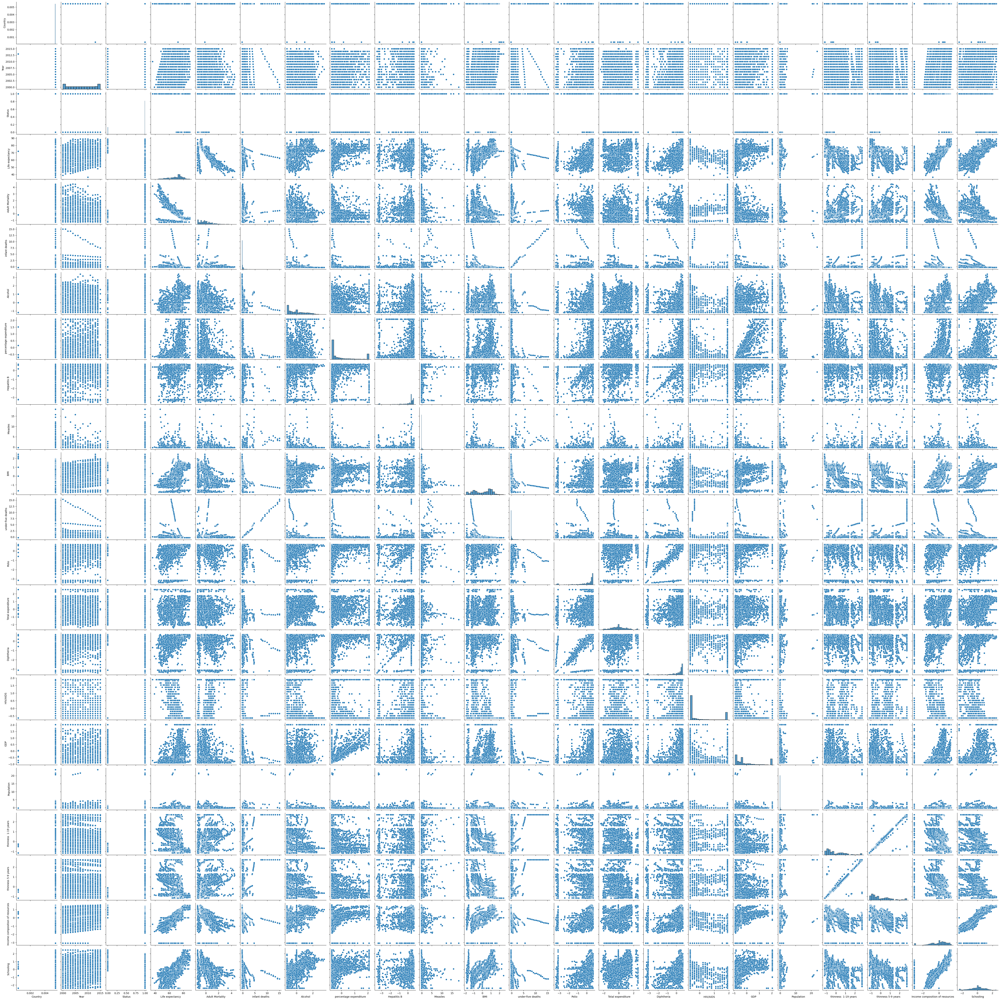

In [46]:
sns.pairplot(data=df)
plt.show()

# Models

In [47]:
# linear regression
X =df.drop('Life expectancy ', axis=1)
X

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.005446,2015,1,0.792119,0.268824,-1.172958,-0.546410,-0.783807,-0.110384,-0.964715,...,-3.279423,0.991344,-0.735391,-0.629209,-0.756835,0.435183,2.711459,2.740246,-0.725401,-0.632374
1,0.005446,2014,1,0.856601,0.285786,-1.172958,-0.540647,-0.914281,-0.168124,-0.989810,...,-1.053699,1.000080,-0.862233,-0.629209,-0.749306,-0.183349,2.711459,2.740246,-0.740050,-0.664624
2,0.005446,2013,1,0.832421,0.302749,-1.172958,-0.541429,-0.827298,-0.173531,-1.014905,...,-0.882489,0.978240,-0.777671,-0.629209,-0.744263,0.398066,2.711459,2.740246,-0.769349,-0.696875
3,0.005446,2012,1,0.864662,0.328193,-1.172958,-0.528678,-0.696824,0.032045,-1.040000,...,-0.668478,1.148594,-0.650830,-0.629209,-0.734146,-0.120968,2.711459,2.740246,-0.803531,-0.729125
4,0.005446,2011,1,0.888843,0.345155,-1.172958,-0.711239,-0.653333,0.051757,-1.060076,...,-0.625675,0.864671,-0.608549,-0.629209,-0.894692,-0.134268,2.711459,2.740246,-0.847480,-0.825876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0.005446,2004,1,4.499850,-0.028022,-0.062024,-0.729465,-0.653333,-0.208332,-0.563194,...,-0.668478,0.541437,-0.735391,1.895041,-0.791223,0.047149,1.198386,1.180722,-1.076989,-0.922627
2934,0.005446,2003,1,4.435368,-0.036503,-0.138640,-0.729465,-3.306306,-0.123991,-0.583270,...,-3.236620,0.274987,-0.608549,1.895041,-0.791492,0.044490,1.300105,1.306490,-1.023274,-0.825876
2935,0.005446,2002,1,-0.739335,-0.044984,-0.044146,-0.729465,-0.435876,-0.184521,-0.603346,...,-0.411663,0.279355,-0.481708,1.895041,-0.896330,-0.187090,-0.886858,-0.856721,-0.979326,-0.664624
2936,0.005446,2001,1,4.201620,-0.044984,-0.736246,-0.729465,-0.305402,-0.164897,-0.623422,...,-0.283256,0.117738,-0.312585,1.895041,-0.766279,0.039533,-0.785139,-0.756107,-0.979326,-0.729125


In [48]:
y = df['Life expectancy ']
y

0       65.0
1       59.9
2       59.9
3       59.5
4       59.2
        ... 
2933    44.3
2934    44.5
2935    44.8
2936    45.3
2937    46.0
Name: Life expectancy , Length: 2938, dtype: float64

In [49]:
# splitting
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [50]:
# training
model =  LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
# predict
predictions = model.predict(X_test)
predictions

array([69.34206586, 78.50631354, 75.97623467, 77.38073293, 50.47882724,
       49.70308087, 69.90626797, 71.80124186, 76.24376091, 57.29710347,
       50.94538339, 58.10918336, 60.14480079, 71.88126239, 71.88432242,
       57.51223825, 57.13761648, 80.63985429, 61.49959189, 80.4122086 ,
       80.65464466, 82.96440333, 71.5818908 , 69.45280017, 71.6307629 ,
       61.466429  , 62.2828584 , 62.82730896, 80.14549617, 73.4574281 ,
       67.34365618, 75.45325743, 69.22192162, 64.7688636 , 79.14328541,
       58.25789484, 62.07459101, 72.35515725, 65.26674223, 76.14335895,
       53.55983442, 59.062333  , 75.33330252, 81.46739817, 76.31871844,
       56.83494802, 79.46497293, 70.97219529, 66.72515054, 68.93556911,
       58.21880586, 62.38338863, 78.016117  , 73.42813357, 73.3158236 ,
       57.05242687, 78.62823023, 72.80780541, 69.05066318, 70.45768132,
       77.01437932, 52.0507053 , 73.61935672, 68.35773863, 50.49651642,
       58.57146428, 50.68219939, 81.34720959, 56.56673098, 77.70

In [52]:
# Mse and R2
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test,predictions)
print(f'MSE = {mse}')
r2 = r2_score(y_test,predictions)
r2

MSE = 13.138111221075617


0.8594836656331022

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [54]:
# Ridge
ridge = Ridge(alpha=1.0)
ridge_results = evaluate_model(ridge, X_train, X_test, y_train, y_test)
print(ridge_results)

(2.701521634507328, np.float64(3.623905232288818), 0.8595416566169616)


In [55]:
# Lasso
lasso = Lasso(alpha=0.01)
lasso_results = evaluate_model(lasso, X_train, X_test, y_train, y_test)
print(lasso_results)

(2.7162733392664564, np.float64(3.640089345018026), 0.8582843005435052)


In [59]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:58
    --------------------------------------- 1.3/101.7 MB 1.8 MB/s eta 0:00:58
    --------------------------------------- 1.6/101.7 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 2.1/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 2.4/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 2.9/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 3.1/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 3.4/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 3.9/101.7 MB 1.8 MB/s eta 0:00:56



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [61]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(rf, X_train, X_test, y_train, y_test)

In [62]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [63]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [106]:
xgb_results = xgb.predict(X_test)

In [107]:
xgb_results

array([72.90347 , 75.69535 , 74.85173 , 75.99306 , 53.20391 , 53.571213,
       66.022934, 73.97468 , 77.0539  , 54.622623, 52.544518, 54.621437,
       55.783398, 74.79505 , 70.07324 , 62.022194, 57.784637, 79.419395,
       71.56562 , 79.36064 , 80.364876, 84.494606, 72.89645 , 68.33902 ,
       72.480125, 69.46959 , 57.30889 , 65.75982 , 82.626495, 76.70914 ,
       67.79293 , 74.063515, 75.48828 , 71.8806  , 78.14412 , 49.856926,
       62.112625, 72.98333 , 63.507835, 74.05375 , 55.08008 , 61.294155,
       75.52814 , 79.94084 , 76.74119 , 47.852955, 81.01528 , 75.38151 ,
       59.76061 , 72.830444, 52.64001 , 71.30696 , 82.06663 , 79.78015 ,
       73.87464 , 59.947323, 73.34382 , 75.59858 , 62.83912 , 69.11672 ,
       78.63936 , 54.736732, 74.49997 , 72.11394 , 51.65739 , 55.082836,
       52.511078, 76.645226, 60.49709 , 70.8085  , 83.293915, 78.2347  ,
       73.53975 , 53.53603 , 55.878147, 68.27643 , 64.00054 , 74.32463 ,
       55.39907 , 62.160984, 63.48161 , 62.599155, 

In [66]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_results = evaluate_model(lr, X_train, X_test, y_train, y_test)
print(lr_results)

(2.7032803992069785, np.float64(3.624653255288789), 0.8594836656331022)


In [108]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Random Forest", "XGBoost"],
    "MAE": [
        lr_results[0],
        ridge_results[0],
        lasso_results[0],
        rf_results[0],
        xgb_results[0]
    ],
    "RMSE": [
        lr_results[1],
        ridge_results[1],
        lasso_results[1],
        rf_results[1],
        xgb_results[1]
    ],
    "R2 Score": [
        lr_results[2],
        ridge_results[2],
        lasso_results[2],
        rf_results[2],
        xgb_results[2]
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.703280,3.624653,0.859484
1,Ridge,2.701522,3.623905,0.859542
2,Lasso,2.716273,3.640089,0.858284
3,Random Forest,1.162246,1.825662,0.964352
4,XGBoost,72.903473,75.695351,74.851730


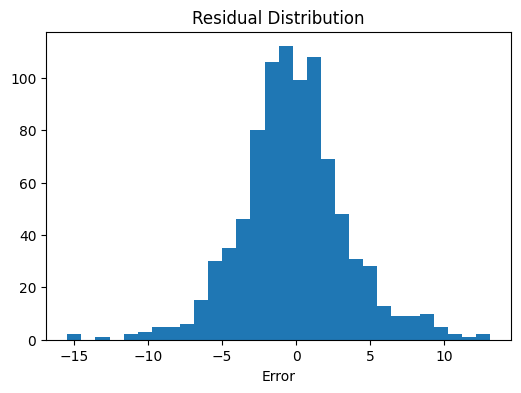

In [68]:
residuals = y_test - predictions

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

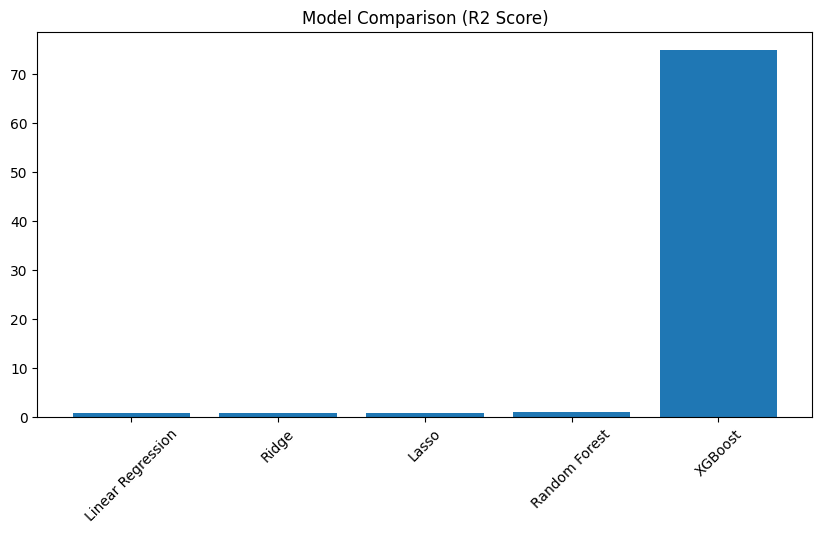

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

In [70]:
fig = px.bar(x=["Linear", "Ridge", "RF", "XGB"], y=[0.7, 0.72, 0.85, 0.90])
fig.show()

In [78]:
# Single Color
import plotly.io as pio
pio.renderers.default = "vscode"
ig=px.histogram(df,x='Life expectancy ',template='plotly_dark')
fig.show()

In [79]:
fig=px.histogram(df,x='Life expectancy ',template='plotly_dark')
fig.show()

In [100]:
fig=px.violin(df,x='Status',y='Life expectancy ',color='Status',template='plotly_dark',box=True,title='Life expectancy Based on Countries status')
fig.show()

In [103]:
fig=px.line(df.sort_values(by='Year'),x='Year',y='Life expectancy ',animation_frame='Country',animation_group='Year',color='Country',markers=True,template='plotly_dark',title='<b> Country wise Life Expectancy over Years')
fig.show()

In [104]:
px.scatter(df,y='Adult Mortality',x='Life expectancy ',color='Country',size='Life expectancy ',template='plotly_dark',opacity=0.6,title='<b> Life Expectancy Versus Adult Mortality')

In [84]:
px.scatter(df,x='Life expectancy ',y='percentage expenditure',color='Country',size='Year',template='plotly_dark',title='<b> Life Expectancy Versus Percentage expenditure')

#### DECREASE IN INFANT DEATHS INCREASES LIFE EXPECTANCY

In [85]:
px.scatter(df.sort_values(by='Year'),y='infant deaths',x='Life expectancy ',template='plotly_dark',size='Year',color='Country',opacity=0.6,title='<b>Life Expectancy Versus Infant Deaths of Countries in every Year')

In [93]:
import plotly.express as px

df_plot = df.sort_values(by='Year').copy()

# Shift to make all values positive for size
df_plot['expenditure_size'] = df_plot['Total expenditure'] - df_plot['Total expenditure'].min() + 0.1

px.scatter_3d(
    df_plot,
    x='Life expectancy ',
    y='Schooling',
    z='Total expenditure',
    color='Country',
    size='expenditure_size',   # use shifted column for size
    template='plotly_dark',
    title='Life Expectancy: Schooling vs Expenditure (3D)',
    opacity=0.7,
)

In [87]:
px.scatter_3d(df.sort_values(by='Year'),y='Adult Mortality',x='Life expectancy ',z='infant deaths',size='Life expectancy ',template='plotly_dark',color='Country')

In [89]:
px.scatter(df.sort_values(by='Year'),y='Schooling',x='Life expectancy ',animation_frame='Year',animation_group='Country',template='plotly_dark',color='Country',size='Life expectancy ',title='<b> Life expectancy versus Schooling of countries in every year')

In [90]:
px.scatter(df.sort_values(by='Year'),y='Adult Mortality',x='Life expectancy ',animation_frame='Year',animation_group='Country',color='Country',size='Life expectancy ',opacity=0.6,template='plotly_dark',title='<b> Life Expectancy Versus Adult Mortality in every year')

In [91]:
px.scatter(df.sort_values(by='Year'),y='Adult Mortality',x='Life expectancy ',animation_frame='Year',animation_group='Country',color='Country',size='Life expectancy ',opacity=0.6,template='plotly_dark',title='<b> Life Expectancy Versus Adult Mortality in every year')

In [92]:
px.scatter(df.sort_values(by='Year'),y='GDP',x='Life expectancy ',animation_frame='Year',animation_group='Country',template='plotly_dark',color='Country',size='Life expectancy ',title='<b>Life Expectancy Versus GDP of Countries in every Year')